## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [1]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df=pd.read_csv('shopping_trends.csv')
df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [6]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [7]:
# TODO: drop the Customer ID column  
df=df.drop(columns='Customer ID')

### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [8]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   str    
 6   Size                      3900 non-null   str    
 7   Color                     3900 non-null   str    
 8   Season                    3900 non-null   str    
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   str    
 11  Payment Method            3900 non-null   str    
 12  Shipping Type             3900 non-null   str    
 13  Discount Applied          3900 non-null   str    
 14  Promo Code Used    

In [12]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [13]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [15]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [18]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']
df.head(5)

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


## **EDA**

### **Item Purchased**

In [19]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
df['Gender'].value_counts().reset_index()

,Gender,count
0,Male,2652
1,Female,1248


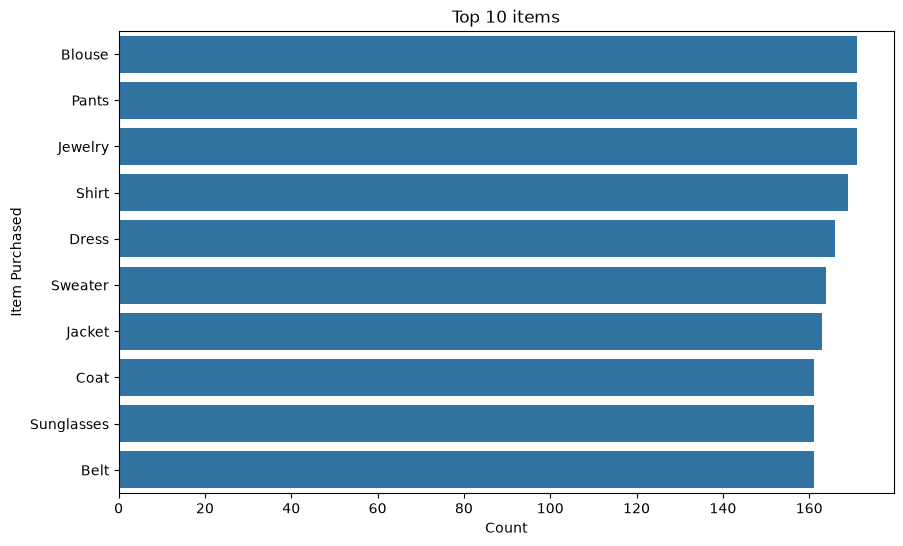

In [22]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
top_10_items = df['Item Purchased'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
     x=top_10_items.values,
     y=top_10_items.index,
     legend=False
 )
plt.title('Top 10 items')
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

<Axes: ylabel='Item Purchased'>

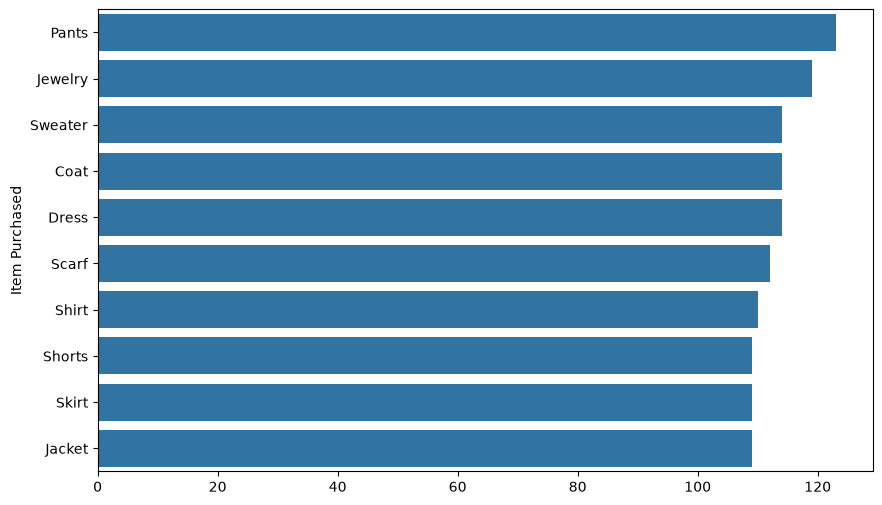

In [ ]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
top_10_items_males=df[df['Gender']=='Male']['Item Purchased'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_10_items_males.values,
    y=top_10_items_males.index,
    legend=False
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [ ]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
top_10_items_females=df[df['Gender']=='Female']['']
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_f.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
# plt.title("Top 10 Purchased Items by Females")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()

In [53]:
# TODO: count Size with value_counts() for all customers


In [54]:
# TODO: count Size with value_counts() for male_df and female_df


### **Category**

In [55]:
# TODO: count Category with value_counts().reset_index() for all customers
# ctg = ?

In [56]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df


In [57]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#     ?
# )
# plt.title("Preferred Category by Males")
# plt.xlabel('Category')
# plt.ylabel('count')
# plt.show()

In [58]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.xlabel('Category')
# plt.ylabel('count')
# plt.show()

In [59]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#     data=ctg,
#     x='Category',
#     y='count',
#     hue='Category',
#     dodge=False,
#     legend=False
# )
# plt.title("Preferred Category by both Genders")
# plt.show()


In [60]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
# waffle_data_m = dict(male_df['Category'].value_counts())
# waffle_data_f = dict(female_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()


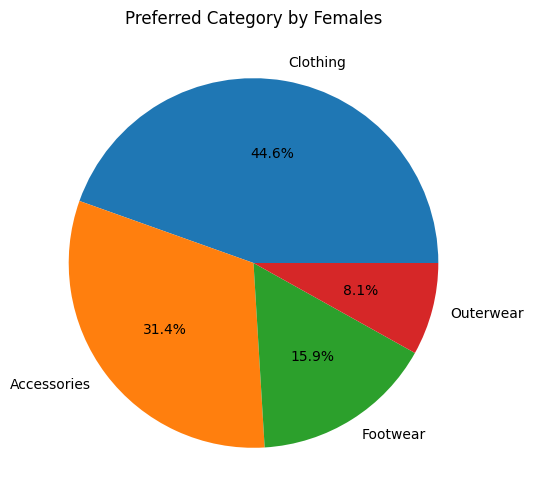

In [ ]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
# plt.figure(figsize=(6, 6))
# plt.pie(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.show()

In [62]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
# plt.figure(figsize=(6, 6))
# plt.pie(
#     waffle_data_m.values(),
#     labels=waffle_data_m.keys(),
#     autopct='%1.1f%%'
# )
# plt.title("Preferred Category by Males")
# plt.show() 

### **Review ratings**

In [ ]:
# TODO: filter female Clothing rows, then mean of Review Rating
# cr_f = ?
# avg_cr_f = ?

In [ ]:
# TODO: filter male Clothing rows, then mean of Review Rating
# cr_m = ?
# avg_cr_m = ?

In [ ]:
# avg_cr_m,avg_cr_f

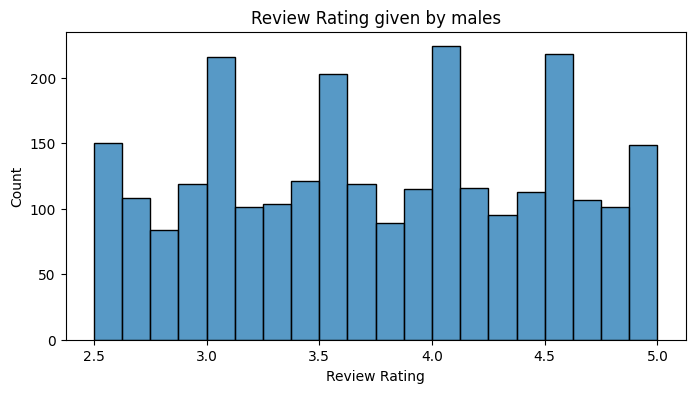

In [73]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
# ?

In [65]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)


### **Purchase Amount (USD)**

In [ ]:
# TODO: sum Purchase Amount (USD) for males
# m_tpa = ?

# # TODO: sum Purchase Amount (USD) for females
# f_tpa =?

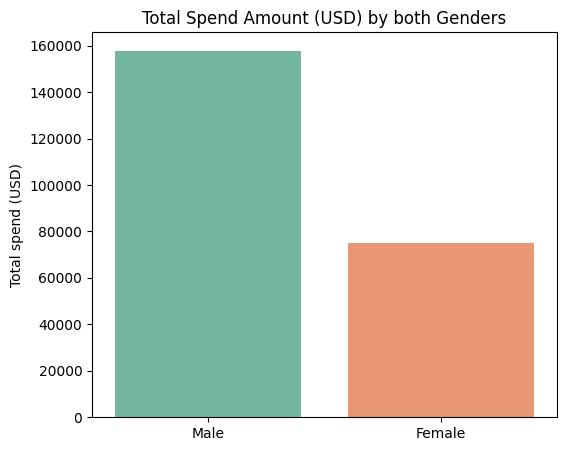

In [ ]:
# TODO: plot total spend by gender with sns.barplot()
# plt.figure(figsize=(6, 5))
# sns.barplot(
#     ?
# )
# plt.title("Total Spend Amount (USD) by both Genders")
# plt.ylabel('Total spend (USD)')
# plt.show()

In [69]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
# cc_f = cr_f
# ca_f = female_df[female_df['Category']=='Accessories']
# cf_f = ?
# co_f = ?

In [ ]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
# cc_m = cr_m
# ca_m = ?
# cf_m = ?
# co_m = ?

In [72]:
# TODO: create pcu dict from Promo Code Used value_counts()


### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

In [74]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()


### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [ ]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
# df = pd.get_dummies(df, columns=[?], dtype=?)
# df.head()

In [ ]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# df['Amount_minmax'] = ?
# df['Age_standard'] = ?
# df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

In [ ]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
# df['Amount_bin'] = ?
# df['Amount_bin'].value_counts()

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- 
- 
- 
- 

Caveat: correlation is not causation.